## <code>data-conduit</code>: Overview and Workflow Guide
**A Python Toolkit for Constructing Standardised, Reusable Data Pipelines for Multi-Stream Experimental Data**

## Table of Contents

1. [What is `data-conduit`?](#1-what-is-data-conduit)
2. [How does `data-conduit` work?](#2-how-does-data-conduit-work)
3. [An overview of `data-conduit`'s modules](#3-an-overview-of-data-conduits-modules)
4. [Part 1: IO — Discovering and reading files](#4-io)
5. [Part 2: The object layer — DataSource, Device, FileTypeData, MultiSource, MultiDevice](#5-object-layer)
6. [Part 3: TTL synchronisation and temporal alignment](#6-ttlsync)
7. [Putting it all together](#7-putting-it-all-together)
8. [Useful information and links](#8-links)

-----
## 1. What is `data-conduit`?

`data-conduit` is a Python toolkit for converting outputs from multiple data acquisition sources into consistent, unified data structures that can be used for subsequent analysis.

This library was originally designed for experimental neuroscience labs working with the [Bonsai](https://bonsai-rx.org/) and [HARP](https://harp-tech.org/) ecosystems as part of their workflow, with raw experimental data stored in directories based on the [NeuroBlueprint](https://neuroblueprint.neuroinformatics.dev/) standard. However, most functionalities provided by `data-conduit` are modular and flexible, and should be compatible with other data acquisition platforms, as well as other data conventions.`data-conduit` is concerned with using a consistent structure to automate data processing workflows, rather than enforcing any one particular format.

These workflows are designed to integrate with tools from the broader [neuroinformatics.dev](https://neuroinformatics.dev/) ecosystem, including [datashuttle](https://datashuttle.neuroinformatics.dev/) for data management and [movement](https://movement.neuroinformatics.dev/) for pose tracking analysis.

The functionality of `data-conduit` can be broadly grouped into the following categories:

1. **Automated discovery and reading** of data files from directory trees.
2. **Processing and conversion** of raw data into unified data structures (nested dicts of DataFrames, xarray DataArrays).
3. **Flexible querying utilities** to interact with unified data structures across devices, registers, and data types.
4. **Temporal alignment** of different experimental data streams (e.g. Bonsai/HARP ↔ Neuropixels via TTL synchronisation).
5. **Segmentation** of data using event-based windowing and boolean run-length encoding.

-----
## 2. How does `data-conduit` work?

To explain how `data-conduit` works, it is helpful to first explain how data from HARP devices would normally need to be extracted using the `harp-python` API.

When working with HARP devices, users will find that their experimental data is organised into a hierarchical folder structure, with each device having its own subfolder containing multiple `.bin` files corresponding to different registers. The naming convention follows a consistent pattern: `DeviceName_RegisterAddress_Timestamp.bin`.

A user wanting to access a specific register's data must:
1. Create a device reader from a YAML schema file
2. Know the correct register name and address
3. Construct the correct file path
4. Read the binary data into a DataFrame

In [1]:
#======== How harp-python works natively
import harp

device_yaml_path = '/home/callum/Keshavarzi-Lab-Workspace/data-conduit/device.yml'
device_register_path = '/home/callum/Keshavarzi-Lab-Workspace/data-conduit/JPVA191B_23102025_run1_g0/bonsai/Behavior4/Behavior4_32_1904-01-01T02-00-00.bin'

reader = harp.create_reader(device_yaml_path)
reader.DigitalInputState.read(device_register_path)

,DIPort0,DIPort1,DIPort2,DI3
Time,,,,
8477.558592,True,False,False,False
8477.641888,False,False,False,False
8477.706016,True,False,False,False
8477.838816,False,False,False,False
9536.453216,False,True,False,False
9536.747008,False,False,False,False


**The Problem:**

Whilst these tools provide a basic framework for accessing HARP device data, users will often find themselves working with experiment logs containing multiple devices and multiple registers per device, as well as needing to collate data across sessions, devices, and data types. Using the above approach requires manually repeating these steps for every register of interest across every device and session, which both a time-consuming and error-prone process.

**The Solution:**

`data-conduit` exploits the one thing that is consistent across all experimental sessions: **the directory structure itself**. 

For example, data about a particular component connected to a HARP board will always reside at `[device]/[register]/columns`. By defining a mapping that specifies where each variable of interest is located within the experimental directory; such as by using device, register, and column identifiers, the library can automatically discover, load, and organise all relevant data into consistent structures that mirror the physical layout of the rig.

This means users work with **stable variable names** instead of file paths. The same code works unchanged across sessions, rigs, and experiments, as long as the directory layout is consistent.

----
## 3. An overview of `data-conduit`'s modules

### Package structure

```
data_conduit/
├── io/                  # File discovery and reading
│   ├── io_core.py       # collect_folders, collect_file_paths, collect_dfs
│   └── readers.py       # read_csv, read_harp_bin, read_json, etc.
├── harptools/           # HARP-specific loading
│   └── harptools_core.py  # collect_harp_dfs
├── utils/               # Selector utilities
│   └── utils_core.py    # starts_with, _matches_selector, _parse_selectors
├── datasource/          # Generic object layer
│   ├── datasource_core.py  # DataSource base class
│   ├── devices.py       # Device, SoundCard, CameraStart, Camera0Frames
│   └── filetypes.py     # FileTypeData, ExperimentEvents, RotationData, etc.
├── multisource/         # Multi-stream alignment layer
│   ├── multisource_core.py  # MultiSource
│   └── multidevice.py   # MultiDevice, Nosepoke
├── virtualarrays/       # DataArray construction + querying
│   ├── virtual_arrays_core.py  # construct_data_array, construct_lookup_array
│   ├── base_queries.py  # ulookup
│   └── custom_lookup_template.py  # .ulookup accessor
├── timestamps/          # Timestamp extraction
│   └── timestamps_core.py
├── globaltimes/         # Global clock + index mapping
│   └── globaltimes_core.py
├── ttlsync/             # TTL pulse alignment
│   ├── ttlsync_core.py  # extract_ttl_segments, TTLSyncModel, etc.
│   └── ttl_visualisation.py
├── segment/             # Event windowing + segmentation
├── validators/          # Data validation
└── deprecated/          # Legacy compatibility wrappers
```

### How the layers connect

`data-conduit` is organised into three conceptual layers, each building on the one below:

**Layer 1| IO (functions):** Low-level utilities that discover directories, find files, and read them into DataFrames. These are pure functions with no state.

**Layer 2| Object layer (classes):** Classes that use the IO layer to load data and then organise it into named outputs. There are two families:
- **DataSource** → **Device** / **FileTypeData**: For cases where each output maps to a single location in the directory tree (one device, one register). Produces a dict of named `xr.DataArray` objects.
- **MultiSource** → **MultiDevice**: For cases where a single output combines data from *multiple* locations (e.g. nosepoke activations spread across multiple HARP boards). Produces unified DataArrays with virtual coordinate lookup.

**Layer 3| Alignment & analysis (functions + classes):** Temporal alignment (TTL sync, global clock), segmentation, and querying utilities that operate on the DataArrays produced by Layer 2.

| Layer | Module | Key exports | Purpose |
|---|---|---|---|
| IO | `io` | `collect_folders`, `collect_file_paths`, `collect_dfs` | Walk directories, read files into nested dicts |
| IO | `harptools` | `collect_harp_dfs` | HARP-specific wrapper: collapse, rekey, filter |
| Object | `datasource` | `DataSource` | Generic: dfs_dict → named DataArrays |
| Object | `datasource.devices` | `Device`, `SoundCard`, `Camera0Frames` | HARP device loading + DataSource |
| Object | `datasource.filetypes` | `FileTypeData`, `ExperimentEvents`, `VideoData` | CSV/JSON/YAML loading + DataSource |
| Object | `multisource` | `MultiSource` | Virtual-map aligned multi-stream arrays |
| Object | `multisource.multidevice` | `MultiDevice`, `Nosepoke` | HARP loading + MultiSource |
| Query | `virtualarrays` | `ulookup`, `.ulookup` accessor | Query DataArrays by virtual coordinates |
| Align | `ttlsync` | `extract_ttl_segments`, `TTLSyncModel` | TTL pulse alignment between clock domains |
| Align | `globaltimes` | `create_global_clock`, `index_map_util` | Shared timebase + index mapping |

----
## 4. Part 1: IO| Discovering and reading files

The IO layer provides the building blocks that every higher-level class uses internally. This is central to much of the rest of the library, as every class in `data-conduit` ultimately calls these functions at some stage.


### 4.1 Setup

In [2]:
#======== User-Configurable Paths ==============================================
experiment_directory_path = '/home/callum/Keshavarzi-Lab-Workspace/data-conduit/Misc/2025-10-14T18-24-42'
harp_device_yaml_path     = '/home/callum/Keshavarzi-Lab-Workspace/data-conduit/device.yml'
soundcard_yaml_path       = '/home/callum/Keshavarzi-Lab-Workspace/data-conduit/soundcard.yml'
npx_sync_path             = '/home/callum/Keshavarzi-Lab-Workspace/data-conduit/Misc/sync_channel_1014.npy'

### 4.2 Directory discovery

A typical Bonsai experiment produces a directory tree like:

```
experiment/
├── Behavior0/
│   └── Behavior0/
│       ├── Behavior0_32_2024-01-01T12-00-00.bin
│       └── Behavior0_34_2024-01-01T12-00-00.bin
├── Behavior1/ ...
├── SoundCard/ ...
├── ExperimentEvents/
│   └── ExperimentEvents.csv
└── VideoData/
    └── VideoData.csv
```

`collect_folders` lists subdirectories. `collect_file_paths` finds files matching given extensions.

In [3]:
from data_conduit.io import collect_file_paths, collect_folders

In [4]:
# List all top-level folders
folders = collect_folders(experiment_directory_path)
print('Top-level folders:')
for f in folders:
    print(f'  {f.name}')

print()

# Find all .bin files
bin_files = collect_file_paths(base_path= experiment_directory_path, file_pattern='*.bin')
print(f'Found {len(bin_files)} .bin files (showing first 5):')
for p in bin_files:
    print(f'  {p}')

Top-level folders:
  Behavior0
  Behavior1
  Behavior2
  Behavior3
  Behavior4
  Behavior5
  ExperimentEvents
  InnerRotation
  NosepokeRotation
  OuterRotation
  SessionSettings
  SoundCard
  VideoData
  VisualEnvironment

Found 7 .bin files (showing first 5):
  Behavior0
  Behavior1
  Behavior2
  Behavior3
  Behavior4
  Behavior5
  SoundCard


### 4.3 `collect_dfs`| the core directory walker

`collect_dfs` is the engine behind everything else. It walks a directory tree, reads every file it can, and returns a **nested dictionary** that mirrors the folder structure, where each leaf is a DataFrame.

Users control behaviour with two things:
- **`readers`**: a dict mapping file extensions to reader functions (e.g. `{'.csv': read_csv}`)
- **`l{n}_selector`**: level selectors that filter which folders/files are included at each depth

The result is always a nested dict. This is the fundamental data structure that flows through the entire library.

In [5]:
from data_conduit.io import collect_dfs, read_csv

# Load all CSV files from the experiment directory
csv_dfs = collect_dfs(
    base_path=experiment_directory_path,
    readers={'.csv': read_csv},
    verbose=True,
)

print('\nLoaded structure:')
for key, value in csv_dfs.items():
    if isinstance(value, dict):
        print(f'  {key}/ -> {list(value.keys())}')
    else:
        print(f'  {key} -> {type(value).__name__} {getattr(value, "shape", "")}')

Failed to read /home/callum/Keshavarzi-Lab-Workspace/data-conduit/Misc/2025-10-14T18-24-42/VisualEnvironment/VisualEnvironment_1904-01-01T08-00-00.csv with reader for .csv: Expected 2 fields in line 3, saw 6. Error could possibly be due to quotes being ignored when a multi-char delimiter is used.

Loaded structure:
  Behavior0/ -> []
  Behavior1/ -> []
  Behavior2/ -> []
  Behavior3/ -> []
  Behavior4/ -> []
  Behavior5/ -> []
  ExperimentEvents/ -> ['ExperimentEvents_1904-01-01T08-00-00']
  InnerRotation/ -> ['InnerRotation_1904-01-01T08-00-00']
  NosepokeRotation/ -> ['NosepokeRotation_1904-01-01T08-00-00']
  OuterRotation/ -> ['OuterRotation_1904-01-01T08-00-00']
  SessionSettings/ -> []
  SoundCard/ -> []
  VideoData/ -> ['VideoData_1904-01-01T08-00-00']
  VisualEnvironment/ -> []


### 4.4 Level selectors| filtering the directory tree

Level selectors filter at any depth of the directory tree. They accept:
- **A string**: exact match (`l0_selector='Behavior0'`)
- **A list**: match any item (`l0_selector=['Behavior0', 'Behavior1']`)
- **A callable**: custom logic (`l0_selector=starts_with('Behavior')`)
- **None**: include everything (default)

The `starts_with` helper is particularly useful for Bonsai's naming convention where `Behavior0`, `Behavior1`, etc. share a common prefix.

In [6]:
from data_conduit.utils import starts_with

# Load only ExperimentEvents CSVs
events_only = collect_dfs(
    base_path=experiment_directory_path,
    readers={'.csv': read_csv},
    l0_selector=starts_with('ExperimentEvents'),
)
print('Filtered to ExperimentEvents:', list(events_only.keys()))

# Load only Behavior folders
behavior_csvs = collect_dfs(
    base_path=experiment_directory_path,
    readers={'.csv': read_csv},
    l0_selector=starts_with('Behavior'),
)
print('Filtered to Behavior*:', list(behavior_csvs.keys()))

Filtered to ExperimentEvents: ['ExperimentEvents']
Filtered to Behavior*: ['Behavior0', 'Behavior1', 'Behavior2', 'Behavior3', 'Behavior4', 'Behavior5']


### 4.5 Readers| adding custom file formats

Any function with the signature `(path, **kwargs) -> DataFrame` can be used as a reader. Just map it to a file extension. The built-in readers cover `.csv`, `.json`, `.bin` (HARP), `.jsonl`, `.yml`/`.yaml`.

In [7]:
import pandas as pd


# Example: custom tab-separated reader
def read_tsv(path, **kwargs):
    return pd.read_csv(path, sep='\t', index_col=0, **kwargs)

# Use it like any built-in reader:
# tsv_dfs = collect_dfs(base_path, readers={'.tsv': read_tsv})

# You can also mix readers for different extensions:
# mixed_dfs = collect_dfs(base_path, readers={'.csv': read_csv, '.tsv': read_tsv})

### 4.6 `collect_harp_dfs`| HARP-specific loading

`collect_harp_dfs` wraps `collect_dfs` for the specific needs of HARP binary data. It:

1. Calls `collect_dfs` with the HARP `.bin` reader and a `device_type` prefix filter
2. **Collapses** Bonsai's duplicated device folders (`Behavior0/Behavior0/` → `Behavior0/`)
3. **Rekeys** file stems from `Behavior0_32_timestamp` to just `32` (the register address)
4. **Filters** to only the registers you asked for
5. **Warns** about any expected devices or registers that are missing

The result is a clean `{device: {register: DataFrame}}` dict.

In [8]:
from data_conduit.harptools import collect_harp_dfs

behavior_dfs = collect_harp_dfs(
    base_path=experiment_directory_path,
    harp_device_yaml_path=harp_device_yaml_path,
    device_type='Behavior',
    device_registers={'Behavior0': ['32', '34'], 'Behavior1': ['32', '34']},
    verbose=True,
)

print('\nResult:')
for dev, regs in behavior_dfs.items():
    for reg, df in regs.items():
        print(f'  {dev}/{reg}: {df.shape}')
        display(df.head(3))

Failed to read /home/callum/Keshavarzi-Lab-Workspace/data-conduit/Misc/2025-10-14T18-24-42/Behavior4/Behavior4_1904-01-01T08-00-00.bin with reader for .bin: invalid literal for int() with base 10: '1904-01-01T08-00-00'
Failed to read /home/callum/Keshavarzi-Lab-Workspace/data-conduit/Misc/2025-10-14T18-24-42/Behavior5/Behavior5_1904-01-01T08-00-00.bin with reader for .bin: invalid literal for int() with base 10: '1904-01-01T08-00-00'

Result:
  Behavior0/34: (283, 14)


,DOPort0,DOPort1,DOPort2,SupplyPort0,SupplyPort1,SupplyPort2,Led0,Led1,Rgb0,Rgb1,DO0,DO1,DO2,DO3
Time,,,,,,,,,,,,,,
29876.159488,False,False,False,False,False,False,False,False,False,False,False,True,False,False
29879.203488,False,False,False,False,False,False,False,False,False,False,False,True,False,False
29881.924480,False,False,False,False,False,False,False,False,False,False,False,True,False,False


  Behavior1/34: (283, 14)


,DOPort0,DOPort1,DOPort2,SupplyPort0,SupplyPort1,SupplyPort2,Led0,Led1,Rgb0,Rgb1,DO0,DO1,DO2,DO3
Time,,,,,,,,,,,,,,
29876.159488,False,False,False,False,False,False,False,False,False,False,False,True,False,False
29879.204480,False,False,False,False,False,False,False,False,False,False,False,True,False,False
29881.924480,False,False,False,False,False,False,False,False,False,False,False,True,False,False


  Behavior2/34: (283, 14)


...

,CameraOutput0,CameraOutput1
Time,,
29874.792544,True,False


  Behavior5/8: (969, 1)


,TimestampSeconds
Time,
29873.0,29873
29874.0,29874
29875.0,29875


  Behavior5/92: (58013, 1)


,FrameAcquired
Time,
29874.792576,True
29874.809216,True
29874.825856,True


----
## 5. Part 2: The object layer

### Why do we need classes on top of the IO functions?

`collect_dfs` and `collect_harp_dfs` give you nested dicts of DataFrames. Whilst this is already an obvious improvement over manually extracting each data file, users shalll frequently want other features such as:

1. **Named outputs**: instead of navigating `dfs_dict['Behavior0']['32']`, users would often prefer to use more legible naming such as `soundcard.data_arrays['PlaySoundFreq']` .
2. **Automatic loading**: pass an experiment path and get results, without manually calling IO functions
3. **Reusable presets**: common device configurations (SoundCard, Camera, Nosepoke) should be one-liners
4. **Multi-device combination**: when the same data type spans multiple files, users will require a unified DataArray with a shared time axis to view them simultaneously.

The object layer provides two families of classes to address these needs.

### 5.1 DataSource| the generic base

`DataSource` is the simplest object class. It takes a `dfs_dict` (or builds one via `collect_dfs`) and extracts named `xr.DataArray` outputs using **level selectors**. This uses the same `l{n}_selector` pattern from `collect_dfs`.

```python
# The datasource_data_arrays parameter maps friendly names to selectors:
datasource_data_arrays = {
    'PlaySoundFreq': {'l0_selector': 'SoundCard', 'l1_selector': '32'},
    'StopLog':       {'l0_selector': 'SoundCard', 'l1_selector': '33'},
}
```

Each selector navigates the nested dict to find the right DataFrame, converts it to a DataArray, and stores it under the friendly name. If the selector matches exactly one leaf, the friendly name is used directly. If it matches multiple, each gets a disambiguated key.

`DataSource` will most often not be used directly, but rather custom subclasses such as `Device` and `FileTypeData` will be more practical, as they incorporate further functionalities specific to the use-case at hand.

### 5.2 Device| HARP binary data

`Device` extends `DataSource` for HARP devices. It:
1. Calls `collect_harp_dfs` to build a clean dfs_dict
2. Passes it to `DataSource` with `device_data_arrays` for named output extraction

**Presets** like `SoundCard`, `CameraStart`, and `Camera0Frames` set sensible defaults so common devices are one-liners.

In [9]:
from data_conduit.datasources.presets.harp.devices import Camera0Frames, Device, SoundCard

#======== Using Device directly with explicit config
soundcard_demo = Device(
    experiment_directory_path=experiment_directory_path,
    harp_device_yaml_path=soundcard_yaml_path,
    device_type='SoundCard',
    device_list=['SoundCard'],
    device_registers={'SoundCard': ['8', '32', '33', '35']},
    device_data_arrays={
        'PlaySoundFreq':    {'l0_selector': 'SoundCard', 'l1_selector': '32'},
        'StopLog':          {'l0_selector': 'SoundCard', 'l1_selector': '33'},
        'AttenuationRight': {'l0_selector': 'SoundCard', 'l1_selector': '35'},
    },
)

print("Device data_arrays:", list(soundcard_demo.data_arrays.keys()))
for name, da in soundcard_demo.data_arrays.items():
    print(f"  {name}: {da.sizes}")
    display(da.to_dataframe().head(3))


                  If any files/paths are missing or invalid for the monosource_data_arrays you specified, 
                  you may not see warnings about them. Set verbose=True to enable warnings.
                  
Device data_arrays: ['PlaySoundFreq', 'StopLog', 'AttenuationRight']
  PlaySoundFreq: Frozen({'Time': 4})


,PlaySoundOrFrequency
Time,
30093.312480,880
30093.313056,880
30358.165504,880


  StopLog: Frozen({'Time': 2})


,Stop
Time,
30093.350496,1
30358.169504,1


  AttenuationRight: Frozen({'Time': 2})


,AttenuationRight
Time,
30093.313504,1000
30358.166496,1000


In [10]:
#======== Or use the SoundCard preset (same result, less typing)
soundcard_preset = SoundCard(
    experiment_directory_path=experiment_directory_path,
    harp_device_yaml_path=soundcard_yaml_path,
)
print("SoundCard preset data_arrays:", list(soundcard_preset.data_arrays.keys()))


                  If any files/paths are missing or invalid for the monosource_data_arrays you specified, 
                  you may not see warnings about them. Set verbose=True to enable warnings.
                  
SoundCard preset data_arrays: ['PlaySoundFreq', 'StopLog', 'AttenuationRight']


In [11]:
#======== Camera0Frames preset
camera_frames = Camera0Frames(
    experiment_directory_path=experiment_directory_path,
    harp_device_yaml_path=harp_device_yaml_path,
)

print("Camera0Frames data_arrays:", list(camera_frames.data_arrays.keys()))
for name, da in camera_frames.data_arrays.items():
    display(da.to_dataframe().head(3))


                  If any files/paths are missing or invalid for the monosource_data_arrays you specified, 
                  you may not see warnings about them. Set verbose=True to enable warnings.
                  
Camera0Frames data_arrays: ['Behavior0_Camera0Frame', 'Behavior1_Camera0Frame', 'Behavior2_Camera0Frame', 'Behavior3_Camera0Frame', 'Behavior4_Camera0Frame', 'Behavior5_Camera0Frame']


,FrameAcquired
Time,
29874.791584,True
29874.808224,True
29874.824896,True


,FrameAcquired
Time,
29874.791584,True
29874.808224,True
29874.824896,True


,FrameAcquired
Time,
29874.792576,True
29874.809216,True
29874.825856,True


,FrameAcquired
Time,
29874.792576,True
29874.809216,True
29874.825888,True


,FrameAcquired
Time,
29874.792576,True
29874.809216,True
29874.825888,True


,FrameAcquired
Time,
29874.792576,True
29874.809216,True
29874.825856,True


### 5.3 FileTypeData | CSV, JSON, YAML files

Alongside HARP binary data, Bonsai workflows produce CSV, JSONL, and YAML files for experiment events, video metadata, visual environments, and session settings.

`FileTypeData` extends `DataSource` for these file types. It maps a `file_type` string (e.g. `'csv'`) to the appropriate reader, handles Bonsai's double-folder quirk, applies column/index renaming, and splits JSONL/YAML files into metadata + trials.

Like Device, it produces `.data_arrays` as the primary interface. A `.df` convenience property is also available for backward compatibility, and returns the single leaf DataFrame when there's only one file loaded.

In [12]:
from data_conduit.datasources.monosource.filetypes import ExperimentEvents, VideoData, VisualEnvironment

#======== ExperimentEvents
events = ExperimentEvents(experiment_directory_path=experiment_directory_path)
print(f"ExperimentEvents: {events.df} events")
print(f"data_arrays: {list(events.data_arrays.keys())}")
display(events.df)


                  If any files/paths are missing or invalid for the monosource_data_arrays you specified, 
                  you may not see warnings about them. Set verbose=True to enable warnings.
                  
ExperimentEvents:                                                           Event
Time                                                           
29872.322976                                   Workflow started
29874.790976                               Request camera start
29875.153984                                   Start Sync Pulse
29875.629984                                  Start trial logic
29875.894976                                        Trial start
29875.894976                                  Rotating nosepoke
29875.924992                           Start mismatch rotations
29878.962976                         Performing outer rotations
29888.980992  Target zone available (X Y : 395 290 - Radius ...
30113.034976                              Target zone trigg

,Event
Time,
29872.322976,Workflow started
29874.790976,Request camera start
29875.153984,Start Sync Pulse
29875.629984,Start trial logic
29875.894976,Trial start
29875.894976,Rotating nosepoke
29875.924992,Start mismatch rotations
29878.962976,Performing outer rotations
29888.980992,Target zone available (X Y : 395 290 - Radius ...


In [13]:
#======== VideoData
video_data = VideoData(experiment_directory_path=experiment_directory_path)
print(f"VideoData: {video_data.df} rows")
display(video_data.df)


                  If any files/paths are missing or invalid for the monosource_data_arrays you specified, 
                  you may not see warnings about them. Set verbose=True to enable warnings.
                  
VideoData:              FrameID       Timestamp
Time                                
29874.792576  489850  29849558403592
29874.809216  489851  29849575068920
29874.825856  489852  29849591735704
29874.842528  489853  29849608401160
29874.859200  489854  29849625063616
...              ...             ...
30841.322496  547844  30816074286136
30841.339168  547845  30816090952512
30841.355840  547846  30816107618864
30841.372480  547847  30816124285056
30841.389152  547848  30816140950840

[57999 rows x 2 columns] rows


,FrameID,Timestamp
Time,,
29874.792576,489850,29849558403592
29874.809216,489851,29849575068920
29874.825856,489852,29849591735704
29874.842528,489853,29849608401160
29874.859200,489854,29849625063616
...,...,...
30841.322496,547844,30816074286136
30841.339168,547845,30816090952512
30841.355840,547846,30816107618864


In [14]:
#======== VisualEnvironment
vis_env = VisualEnvironment(experiment_directory_path=experiment_directory_path)
print(f"VisualEnvironment: {vis_env.df.shape[0]} rows, columns: {list(vis_env.df.columns)}")
display(vis_env.df.head())


                  If any files/paths are missing or invalid for the monosource_data_arrays you specified, 
                  you may not see warnings about them. Set verbose=True to enable warnings.
                  
VisualEnvironment: 4 rows, columns: ['Value', 'Landmark', 'Landmark_Proximal', 'Gratings', 'Firefly']


,Value,Landmark,Landmark_Proximal,Gratings,Firefly
Time,,,,,
29875.880000,Visual environment OFF,None,None,None,None
29878.962976,Visual environment ON,Landmark spheric photo - botanical garden tree...,Prox Landmarktransparent image - paradise bird...,Gratings : OFF,Firefly : OFF
30113.132992,Visual environment OFF,None,None,None,None
30116.152000,Visual environment ON,Landmark spheric photo - botanical garden tree...,Prox Landmarktransparent image - paradise bird...,Gratings : OFF,Firefly : OFF


### 5.4 MultiSource| combining data across multiple sources

`DataSource` works well when each output maps to a single location in the directory tree. However, with workflows such as the example here, users can find themselves with peripherals or other data that spans multiple locations. 

Consider a rig with 2 HARP Behavior boards, each with 3 nosepoke ports. The activation data for nosepoke 0 lives at `Behavior0/register_32/DIPort0`, while nosepoke 5 is at `Behavior1/register_32/DIPort2`. To analyse all 6 nosepokes together requires a single DataArray with the following:
- A **Time** dimension (merged timestamps from both boards)
- A **peripherals** dimension (6 nosepoke names: NP_0 through NP_5)
- **Virtual coordinates** (device, register, localID) attached to each peripheral to allow them to be queried based on multiple associated values. 

This is what `MultiSource` does. It takes:
1. A `dfs_dict` (nested dict of DataFrames)
2. A `virtual_maps` dict that maps each global name → {device, register, localID}
3. A list of `data_keys` (one per data type: Activations, LEDs, Valves, Rewards)

And produces unified DataArrays + lookup arrays for each data key.

### 5.5 Defining the rig layout

Before using MultiSource/MultiDevice, the user is required to define the physical wiring of their setup. This is the only manual step, allowing the rest to be automated.

| Concept | What it means | Example |
|---|---|---|
| **Device** | A HARP board in the experiment directory | `Behavior0`, `Behavior1` |
| **Register** | An address on a device logging a particular signal | `32` (DigitalInputState), `34` (DigitalOutputState) |
| **LocalID** | A column within a register DataFrame — one per physical port | `DIPort0`, `DOPort1` |
| **Global name** | A user-chosen label for a specific peripheral | `Nosepoke0`, `Nosepoke3` |
| **Virtual map** | Maps each global name → `{device, register, localID}` | `{'Nosepoke0': {'device': 'Behavior0', ...}}` |

In [15]:
#======== Rig Layout =============================================================
# For this demo: 2 Behavior boards, 3 nosepokes each = 6 total

device_list = ['Behavior0', 'Behavior1']
device_registers = {
    'Behavior0': ['32', '34'],
    'Behavior1': ['32', '34'],
}

peripheral_list = [
    'Nosepoke0', 'Nosepoke1', 'Nosepoke2',   # Behavior0
    'Nosepoke3', 'Nosepoke4', 'Nosepoke5',   # Behavior1
]

#======== Virtual Maps ===========================================================
# One map per data type. Each maps a global name to (device, register, localID).

virtual_maps = {
    'Activations': {
        'Nosepoke0': {'device': 'Behavior0', 'register': '32', 'localID': 'DIPort0'},
        'Nosepoke1': {'device': 'Behavior0', 'register': '32', 'localID': 'DIPort1'},
        'Nosepoke2': {'device': 'Behavior0', 'register': '32', 'localID': 'DIPort2'},
        'Nosepoke3': {'device': 'Behavior1', 'register': '32', 'localID': 'DIPort0'},
        'Nosepoke4': {'device': 'Behavior1', 'register': '32', 'localID': 'DIPort1'},
        'Nosepoke5': {'device': 'Behavior1', 'register': '32', 'localID': 'DIPort2'},
    },
    'LED_Activations': {
        'Nosepoke0': {'device': 'Behavior0', 'register': '34', 'localID': 'DOPort0'},
        'Nosepoke1': {'device': 'Behavior0', 'register': '34', 'localID': 'DOPort1'},
        'Nosepoke2': {'device': 'Behavior0', 'register': '34', 'localID': 'DOPort2'},
        'Nosepoke3': {'device': 'Behavior1', 'register': '34', 'localID': 'DOPort0'},
        'Nosepoke4': {'device': 'Behavior1', 'register': '34', 'localID': 'DOPort1'},
        'Nosepoke5': {'device': 'Behavior1', 'register': '34', 'localID': 'DOPort2'},
    },
}
data_keys = list(virtual_maps.keys())

print("Activations virtual_map:")
for ch, coords in virtual_maps['Activations'].items():
    print(f"  {ch} → {coords}")

Activations virtual_map:
  Nosepoke0 → {'device': 'Behavior0', 'register': '32', 'localID': 'DIPort0'}
  Nosepoke1 → {'device': 'Behavior0', 'register': '32', 'localID': 'DIPort1'}
  Nosepoke2 → {'device': 'Behavior0', 'register': '32', 'localID': 'DIPort2'}
  Nosepoke3 → {'device': 'Behavior1', 'register': '32', 'localID': 'DIPort0'}
  Nosepoke4 → {'device': 'Behavior1', 'register': '32', 'localID': 'DIPort1'}
  Nosepoke5 → {'device': 'Behavior1', 'register': '32', 'localID': 'DIPort2'}


### 5.6 MultiDevice| HARP loading + MultiSource

`MultiDevice` combines `collect_harp_dfs` (for loading) with `MultiSource` (for virtual-map construction). When instantiated with an `experiment_directory_path`, it automatically:

1. Calls `collect_harp_dfs` to load DataFrames from all device folders
2. Collects and merges timestamps across devices for each data_key
3. Constructs a base `xr.DataArray` per data_key with unified peripheral names and a shared time axis
4. Constructs a lookup array per data_key mapping each peripheral to its virtual coordinates
5. Fills the DataArrays with actual values from the loaded DataFrames

In [16]:
from data_conduit.datasources.presets.harp.multidevice import MultiDevice

multidevice = MultiDevice(
    experiment_directory_path=experiment_directory_path,
    harp_device_yaml_path=harp_device_yaml_path,
    device_type='Behavior',
    device_list=device_list,
    device_registers=device_registers,
    virtual_maps=virtual_maps,
    data_keys=data_keys,
    global_coord_name='peripherals',
    virtual_coord_names=['device', 'register', 'localID'],
    verbose=False,
)

#### Inspecting the outputs

The `data_arrays` dictionary contains one `xr.DataArray` per data_key. Each has:
- A **Time** dimension containing merged, sorted timestamps from all devices
- A **peripherals** dimension containing the unified peripheral names
- Virtual coordinate arrays (**device**, **register**, **localID**) attached along the peripherals dimension

In [17]:
print(f"data_arrays keys: {list(multidevice.data_arrays.keys())}\n")

for dk in multidevice.data_arrays:
    da = multidevice.data_arrays[dk]
    print(f"\n{'='*60}")
    print(f"{dk}: dims={da.dims}, shape={da.shape}")
    print(f"{'='*60}")
    display(da.to_dataframe().unstack('peripherals').drop(columns=['device', 'register', 'localID'], level=0).head(5))

data_arrays keys: ['Activations', 'LED_Activations']


Activations: dims=('Time', 'peripherals'), shape=(1188352, 6)


Activations_data                                          \
peripherals         Nosepoke0 Nosepoke1 Nosepoke2 Nosepoke3 Nosepoke4   
Time                                                                    
29872.289984              NaN       NaN       NaN       NaN       NaN   
29872.290976              NaN       NaN       NaN       NaN       NaN   
29872.292000              NaN       NaN       NaN       NaN       NaN   
29872.292992              NaN       NaN       NaN       NaN       NaN   
29872.293984              NaN       NaN       NaN       NaN       NaN   

                        
peripherals  Nosepoke5  
Time                    
29872.289984       NaN  
29872.290976       NaN  
29872.292000       NaN  
29872.292992       NaN  
29872.293984       NaN


LED_Activations: dims=('Time', 'peripherals'), shape=(1188352, 6)


LED_Activations_data                                          \
peripherals             Nosepoke0 Nosepoke1 Nosepoke2 Nosepoke3 Nosepoke4   
Time                                                                        
29872.289984                  NaN       NaN       NaN       NaN       NaN   
29872.290976                  NaN       NaN       NaN       NaN       NaN   
29872.292000                  NaN       NaN       NaN       NaN       NaN   
29872.292992                  NaN       NaN       NaN       NaN       NaN   
29872.293984                  NaN       NaN       NaN       NaN       NaN   

                        
peripherals  Nosepoke5  
Time                    
29872.289984       NaN  
29872.290976       NaN  
29872.292000       NaN  
29872.292992       NaN  
29872.293984       NaN

#### Accessing the underlying DataFrames

The loaded nested dict is always available as `.dfs_dict`.

In [18]:
dfs_dict = multidevice.dfs_dict

print(f"Top-level keys (devices): {list(dfs_dict.keys())}")
for device in dfs_dict:
    print(f"  {device} registers: {list(dfs_dict[device].keys())}")

print("\nBehavior0, Register 32:")
display(dfs_dict['Behavior3']['32'].head(5) if '32' in dfs_dict.get('Behavior0', {}) else "Not found")

Top-level keys (devices): ['Behavior0', 'Behavior1', 'Behavior2', 'Behavior3', 'Behavior4', 'Behavior5']
  Behavior0 registers: ['34']
  Behavior1 registers: ['34']
  Behavior2 registers: ['34', '35', '44', '78', '8', '92']
  Behavior3 registers: ['34', '35', '44', '78', '8', '92']
  Behavior4 registers: ['34', '35', '44', '78', '8', '92']
  Behavior5 registers: ['34', '35', '44', '78', '8', '92']

Behavior0, Register 32:


'Not found'

#### The Nosepoke preset

`Nosepoke` is a subclass of `MultiDevice` with pre-built defaults for a standard 6-board × 3-port nosepoke layout (18 nosepokes, 4 data types). For this demo with only 2 boards, we pass custom `virtual_maps` directly to `MultiDevice` instead.

In [19]:
#======= Using our custom 2-board layout
nosepoke = MultiDevice(
    experiment_directory_path=experiment_directory_path,
    harp_device_yaml_path=harp_device_yaml_path,
    device_type='Behavior',
    device_list=device_list,
    device_registers=device_registers,
    virtual_maps=virtual_maps,
    data_keys=data_keys,
    global_coord_name='peripherals',
    virtual_coord_names=['device', 'register', 'localID'],
    fill_value=False,
    verbose=False,
)

for dk in nosepoke.data_arrays:
    da = nosepoke.data_arrays[dk]
    print(f"\n{'='*60}")
    print(f"{dk}")
    print(f"{'='*60}")
    display(da.to_dataframe().unstack('peripherals').drop(
        columns=['device', 'register', 'localID'], level=0, errors='ignore'
    ).head(5))


Activations


Activations_data                                          \
peripherals         Nosepoke0 Nosepoke1 Nosepoke2 Nosepoke3 Nosepoke4   
Time                                                                    
29872.289984              0.0       0.0       0.0       0.0       0.0   
29872.290976              0.0       0.0       0.0       0.0       0.0   
29872.292000              0.0       0.0       0.0       0.0       0.0   
29872.292992              0.0       0.0       0.0       0.0       0.0   
29872.293984              0.0       0.0       0.0       0.0       0.0   

                        
peripherals  Nosepoke5  
Time                    
29872.289984       0.0  
29872.290976       0.0  
29872.292000       0.0  
29872.292992       0.0  
29872.293984       0.0


LED_Activations


LED_Activations_data                                          \
peripherals             Nosepoke0 Nosepoke1 Nosepoke2 Nosepoke3 Nosepoke4   
Time                                                                        
29872.289984                  0.0       0.0       0.0       0.0       0.0   
29872.290976                  0.0       0.0       0.0       0.0       0.0   
29872.292000                  0.0       0.0       0.0       0.0       0.0   
29872.292992                  0.0       0.0       0.0       0.0       0.0   
29872.293984                  0.0       0.0       0.0       0.0       0.0   

                        
peripherals  Nosepoke5  
Time                    
29872.289984       0.0  
29872.290976       0.0  
29872.292000       0.0  
29872.292992       0.0  
29872.293984       0.0

### 5.7 `ulookup`| querying virtual coordinates

Every DataArray produced by MultiSource has virtual coordinates attached. The `.ulookup` accessor allows for:
- **Query** which global peripherals match given criteria → returns a list of names
- **Select** the matching slice of the DataArray → returns a new DataArray



In [20]:
#===== Inspect the lookup array
activations_lookup = nosepoke.lookup_arrays['Activations']

print("Lookup array shape:", activations_lookup.shape)
print("Dims:", activations_lookup.dims)
print("Coords:")
for c in activations_lookup.coords:
    print(f"  {c}: {activations_lookup.coords[c].values}")

Lookup array shape: (6,)
Dims: ('peripherals',)
Coords:
  peripherals: ['Nosepoke0' 'Nosepoke1' 'Nosepoke2' 'Nosepoke3' 'Nosepoke4' 'Nosepoke5']
  device: ['Behavior0' 'Behavior0' 'Behavior0' 'Behavior1' 'Behavior1' 'Behavior1']
  register: ['32' '32' '32' '32' '32' '32']
  localID: ['DIPort0' 'DIPort1' 'DIPort2' 'DIPort0' 'DIPort1' 'DIPort2']


In [21]:
da = nosepoke.data_arrays['Activations']

# Which peripherals belong to Behavior0?
b0 = da.ulookup(device='Behavior0')
print(f"da.ulookup(device='Behavior0') → {b0}")

# Which peripherals belong to Behavior1?
b1 = da.ulookup(device='Behavior1')
print(f"da.ulookup(device='Behavior1') → {b1}")

# Combine selectors: Behavior0 + register 32
specific = da.ulookup(device='Behavior0', register='32')
print(f"da.ulookup(device='Behavior0', register='32') → {specific}")

# Slice the DataArray to just Behavior0
b0_data = da.ulookup.select(device='Behavior0')
print(f"\nSliced to Behavior0: {b0_data.sizes}")
display(b0_data.to_dataframe().unstack('peripherals').drop(columns=['device', 'register', 'localID'], level=0).head(5))

da.ulookup(device='Behavior0') → ['Nosepoke0', 'Nosepoke1', 'Nosepoke2']
da.ulookup(device='Behavior1') → ['Nosepoke3', 'Nosepoke4', 'Nosepoke5']
da.ulookup(device='Behavior0', register='32') → ['Nosepoke0', 'Nosepoke1', 'Nosepoke2']

Sliced to Behavior0: Frozen({'Time': 1188352, 'peripherals': 3})


Activations_data                    
peripherals         Nosepoke0 Nosepoke1 Nosepoke2
Time                                             
29872.289984              0.0       0.0       0.0
29872.290976              0.0       0.0       0.0
29872.292000              0.0       0.0       0.0
29872.292992              0.0       0.0       0.0
29872.293984              0.0       0.0       0.0

-----
## 6. Part 3: TTL synchronisation and temporal alignment

### Why alignment is needed

Bonsai/HARP and Neuropixels run on **independent clocks** that drift over time. To combine behavioural events (HARP timestamps) with neural data (NPX sample indices), a shared time reference is required.

**How it works:**

1. A **TTL square-wave pulse train** is generated and recorded on both systems simultaneously — one copy on a HARP Behavior board (digital IO), one on an NPX sync channel.
2. We **extract** pulse start/end times from both recordings.
3. A **linear model** is fitted mapping NPX time → Bonsai time.
4. Any NPX timestamp can then be **converted** to Bonsai time (and vice versa).

### Step 1: Extract Bonsai-side sync pulses

`Device` can then be used to load the sync board's digital output registers, then build a pulse table.

In [22]:
#==== 1| Extract Bonsai-side sync pulses
import numpy as np
from data_conduit.sync.ttl import build_pulse_table

sync_device = Device(
    experiment_directory_path=experiment_directory_path,
    harp_device_yaml_path=harp_device_yaml_path,
    device_type='Behavior',
    device_list=['Behavior3'],
    device_registers={'Behavior3': ['34', '35']},
    device_data_arrays={
        'DO1_rise': {'l0_selector': 'Behavior3', 'l1_selector': '34'},
        'DO1_fall': {'l0_selector': 'Behavior3', 'l1_selector': '35'},
    },
)

rise_times = sync_device.data_arrays['DO1_rise'].coords['Time'].values
fall_times = sync_device.data_arrays['DO1_fall'].coords['Time'].values

bonsai_pulses = build_pulse_table(rise_times, fall_times)

print(f"Bonsai sync pulses: {len(bonsai_pulses)} detected")
display(bonsai_pulses.head())


                  If any files/paths are missing or invalid for the monosource_data_arrays you specified, 
                  you may not see warnings about them. Set verbose=True to enable warnings.
                  
Bonsai sync pulses: 69 detected


,Start,End,Duration
Pulse,,,
1,29876.160480,29876.922496,0.762016
2,29879.204480,29879.740480,0.536000
3,29881.925504,29884.676480,2.750976
4,29887.621504,29889.694496,2.072992
5,29891.362496,29894.063488,2.700992


### Step 2: Extract NPX-side sync pulses

`extract_ttl_segments` takes a raw sampled waveform and returns a pulse table with Start, End, Duration, and State columns.

In [23]:
#==== 2| Extract NPX-side sync pulses
from data_conduit.sync.ttl import extract_ttl_segments

npx_raw = np.load(npx_sync_path, allow_pickle=True)
npx_frequency = 1  # set to actual NPX sampling rate (e.g. 30000) if data is in samples
npx_times_array = np.arange(len(npx_raw)) / npx_frequency

npx_pulses, npx_offset = extract_ttl_segments(
    times=npx_times_array,
    values=npx_raw,
    threshold=0.1,
    min_duration=0.0,
    align_to_zero=False,
    drop_inactive=True,
)

print(f"NPX sync pulses: {len(npx_pulses)} detected")
display(npx_pulses.head())

NPX sync pulses: 165 detected


,Start,End,Duration,State
0,341852.0,364711.0,22859.0,1
1,433171.0,449250.0,16079.0,1
2,514802.0,597330.0,82528.0,1
3,685682.0,747870.0,62188.0,1
4,797911.0,878940.0,81029.0,1


### Step 3: Align & fit conversion model

`get_ttl_timebase_conversion` aligns both pulse trains, fits a linear model, and optionally visualises the result. Passing `visualisation=True` shows overlaid pulse trains; `error_visualisation_tools=True` adds per-pulse error scatter plots and histograms for verifying sub-millisecond alignment.


Conversion ratio (slope): 0.00003333
Intercept: 29864.765418
R²: 1.0000000000


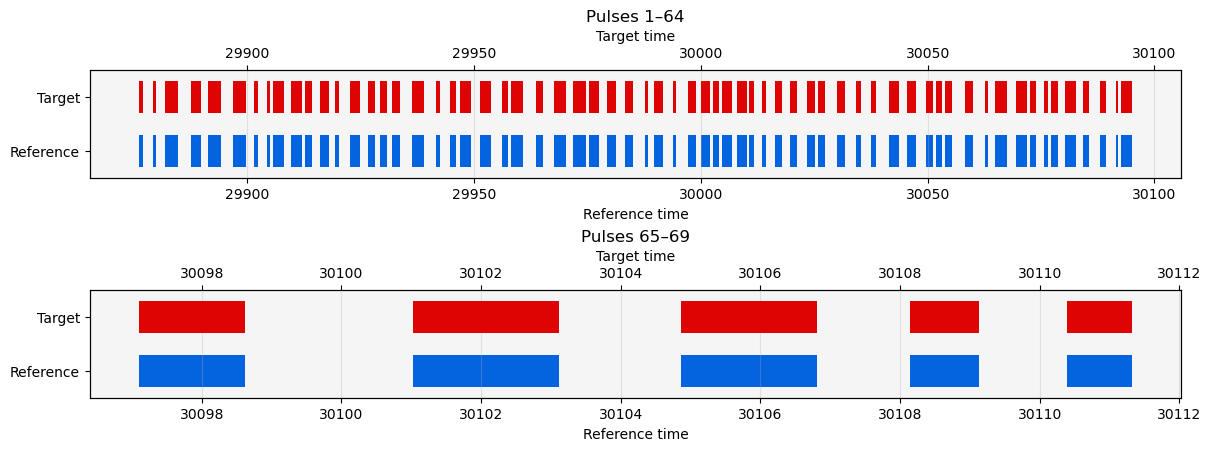

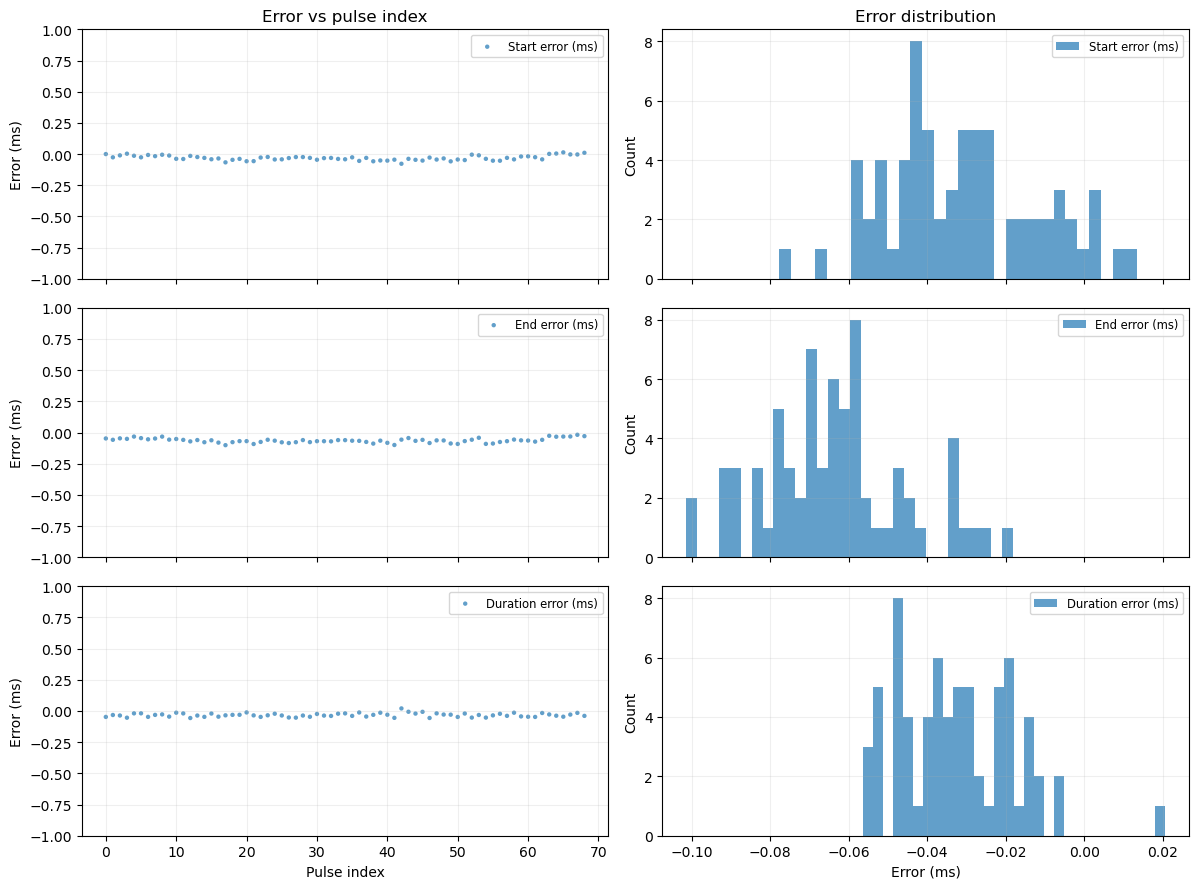

In [24]:
#==== 3| Compute conversion with diagnostics
from data_conduit.sync.ttl import get_ttl_timebase_conversion

converted_df, conversion_ratio, model, fit_stats = get_ttl_timebase_conversion(
    reference_pulses=bonsai_pulses,
    target_pulses=npx_pulses,
    visualisation=True,
    error_visualisation_tools=True,
    return_details=True,
)

print(f"\nConversion ratio (slope): {model.slope:.8f}")
print(f"Intercept: {model.intercept:.6f}")
print(f"R²: {model.r2:.10f}")

### Step 4: Convert arbitrary NPX timestamps

Once the `TTLSyncModel` has been fitted, converting any NPX timestamp to Bonsai time only requires a single call to `model.transform()`.

In [25]:
#==== 4| Convert NPX pulse times to Bonsai time
npx_in_bonsai = npx_pulses.copy()
npx_in_bonsai['Start'] = model.transform(npx_pulses['Start'].values)
npx_in_bonsai['End'] = model.transform(npx_pulses['End'].values)
npx_in_bonsai['Duration'] = npx_in_bonsai['End'] - npx_in_bonsai['Start']

print("NPX pulse durations converted to Bonsai seconds:")
display(npx_in_bonsai.head())

NPX pulse durations converted to Bonsai seconds:


,Start,End,Duration,State
0,29876.160511,29876.922480,0.761968,1
1,29879.204485,29879.740453,0.535968,1
2,29881.925525,29884.676464,2.750940,1
3,29887.621538,29889.694476,2.072938,1
4,29891.362514,29894.063487,2.700973,1


### 5.8 Global clock and index mapping

`create_global_clock` builds a uniformly-spaced time axis (e.g. at 1-second resolution) that serves as the shared index for all data streams. `index_map_util` then maps any stream's timestamps onto this global axis using nearest-match, giving you aligned indices across all modalities.

In [26]:
from data_conduit.globaltimes.globaltimes_core import create_global_clock, index_map_util

# Define session boundaries
bonsai_start = bonsai_pulses['Start'].iloc[0]
bonsai_end = bonsai_pulses['End'].iloc[-1]
print(f"Session: {bonsai_start:.3f} → {bonsai_end:.3f} s, duration: {bonsai_end - bonsai_start:.3f} s")

global_clock = create_global_clock(
    start_time=0.0,
    end_time=bonsai_end - bonsai_start,
    timestep_interval=1,
    include_end_time=True,
)
print(f"Global clock: {len(global_clock)} bins ({global_clock[0]:.3f} → {global_clock[-1]:.3f} s)")

# Map a data stream onto the global clock
activations_da = nosepoke.data_arrays['Activations']
stream_times = activations_da.coords['Time'].values - bonsai_start

result = index_map_util(
    global_clock_times=global_clock,
    stream_times=stream_times,
    match_type='nearest',
)

display(result['full'])
print(f"\nActivations stream: {len(stream_times)} samples")
print(f"Index map keys: {list(result.keys())}")
print(f"Max |Δt| = {np.nanmax(np.abs(result['global_stream_time_delta'])):.6f} s")

Session: 29876.160 → 30111.314 s, duration: 235.154 s
Global clock: 237 bins (0.000 → 235.154 s)


,global_index,stream_index,global_time,stream_time,delta
0,0,4031.0,0.000000,0.000000,0.00000
1,1,5153.0,1.000000,0.999520,0.00048
2,2,6274.0,2.000000,1.999520,0.00048
3,3,7381.0,3.000000,2.999520,0.00048
4,4,8502.0,4.000000,3.999520,0.00048
...,...,...,...,...,...
232,232,286787.0,232.000000,231.999520,0.00048
233,233,288027.0,233.000000,232.999520,0.00048
234,234,289264.0,234.000000,233.999520,0.00048
235,235,290488.0,235.000000,234.999520,0.00048



Activations stream: 1188352 samples
Index map keys: ['index_position_array', 'matched_global_times', 'global_stream_time_delta', 'full']
Max |Δt| = 0.000480 s


In [27]:
test_df= result['full']

test_df

,global_index,stream_index,global_time,stream_time,delta
0,0,4031.0,0.000000,0.000000,0.00000
1,1,5153.0,1.000000,0.999520,0.00048
2,2,6274.0,2.000000,1.999520,0.00048
3,3,7381.0,3.000000,2.999520,0.00048
4,4,8502.0,4.000000,3.999520,0.00048
...,...,...,...,...,...
232,232,286787.0,232.000000,231.999520,0.00048
233,233,288027.0,233.000000,232.999520,0.00048
234,234,289264.0,234.000000,233.999520,0.00048
235,235,290488.0,235.000000,234.999520,0.00048


In [28]:
# Segment test

from data_conduit.segment import get_segment

trial_times = get_segment(data= test_df,
                          start= 5,
                          end= 100,
                          lookup_column= 'global_time',
                          return_column= 'stream_time'
                          )

display(pd.DataFrame(trial_times, columns=['stream_time']))

,stream_time
0,4.99952
1,5.99952
2,6.99952
3,7.99952
4,8.99952
...,...
91,95.99952
92,96.99952
93,97.99952
94,98.99952


----
## 7. Putting it all together

The goal of the whole pipeline is to load every data stream from an experiment and place them into a unified structure with aligned time references. Here we show the complete workflow in a single block

In [29]:
#======== Complete workflow =====================================================
from data_conduit.datasources.presets.harp.devices import Camera0Frames, Device, SoundCard
from data_conduit.datasources.monosource.filetypes import ExperimentEvents, VideoData, VisualEnvironment
from data_conduit.datasources.presets.harp.multidevice import MultiDevice

# 1) Multi-device nosepoke data
nosepoke_data = MultiDevice(
    experiment_directory_path=experiment_directory_path,
    harp_device_yaml_path=harp_device_yaml_path,
    device_type='Behavior',
    device_list=device_list,
    device_registers=device_registers,
    virtual_maps=virtual_maps,
    data_keys=data_keys,
    global_coord_name='peripherals',
    virtual_coord_names=['device', 'register', 'localID'],
    verbose=False,
)

# 2) Single devices
soundcard = SoundCard(
    experiment_directory_path=experiment_directory_path,
    harp_device_yaml_path=soundcard_yaml_path,
)
cameras = Camera0Frames(
    experiment_directory_path=experiment_directory_path,
    harp_device_yaml_path=harp_device_yaml_path,
)

# 3) File-based data
exp_events = ExperimentEvents(experiment_directory_path=experiment_directory_path)
vid_data = VideoData(experiment_directory_path=experiment_directory_path)
vis_environment = VisualEnvironment(experiment_directory_path=experiment_directory_path)

# 4) Print summary
print("=== Session loaded ===")
print(f"  Nosepoke data_keys:  {list(nosepoke_data.data_arrays.keys())}")
print(f"  SoundCard arrays:    {list(soundcard.data_arrays.keys())}")
print(f"  Camera0Frames:       {list(cameras.data_arrays.keys())}")
print(f"  ExperimentEvents:    {exp_events.df}")
print(f"  VideoData:           {vid_data.df}")
print(f"  VisualEnvironment:   {vis_environment.df}")

# 5) Query across devices
activations = nosepoke_data.data_arrays['Activations']
b0_ports = activations.ulookup(device='Behavior0')
b0_slice = activations.ulookup.select(device='Behavior0')
print(f"\n  Behavior0 nosepoke ports: {b0_ports}")
print(f"  Sliced DataArray shape: {b0_slice.sizes}")


                  If any files/paths are missing or invalid for the monosource_data_arrays you specified, 
                  you may not see warnings about them. Set verbose=True to enable warnings.
                  

                  If any files/paths are missing or invalid for the monosource_data_arrays you specified, 
                  you may not see warnings about them. Set verbose=True to enable warnings.
                  

                  If any files/paths are missing or invalid for the monosource_data_arrays you specified, 
                  you may not see warnings about them. Set verbose=True to enable warnings.
                  

                  If any files/paths are missing or invalid for the monosource_data_arrays you specified, 
                  you may not see warnings about them. Set verbose=True to enable warnings.
                  

                  If any files/paths are missing or invalid for the monosource_data_arrays you specified, 
                

----
## 8. Demo Figure: Multi-Stream Session Snapshot

This section builds a prototype **multi-panel figure** that displays a single time-point snapshot of an experiment session, combining:

1. **Video frame** — the camera frame closest to the chosen time
2. **Nosepoke status** — activation state of each nosepoke port over a rolling window
3. **Neural spike raster** — spike times from sorted Neuropixels units in the window
4. **Experiment event log** — recent log messages from ExperimentEvents
5. **Time indicator** — current position within the session

All panels are aligned via the **global clock** and **`get_segment`**, so a single `t_center` parameter controls the view.

In [30]:
#======== 8.1 Load all data streams =============================================

import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from data_conduit.datasources.presets.harp.devices import Camera0Frames, Device
from data_conduit.datasources.monosource.filetypes import ExperimentEvents, VideoData
from data_conduit.globaltimes.globaltimes_core import create_global_clock, index_map_util
from data_conduit.datasources.presets.harp.multidevice import MultiDevice
from data_conduit.segment import get_segment

# --- Paths ---
base_path = '/home/callum/Keshavarzi-Lab-Workspace/data-conduit/JPVA191B_23102025_run1_g0'
experiment_directory_path = f'{base_path}/bonsai'
harp_device_yaml_path     = '/home/callum/Keshavarzi-Lab-Workspace/data-conduit/device.yml'
npx_data_path             = f'{base_path}/NPX'
video_path                = f'{base_path}/bonsai/VideoData/VideoData_1904-01-01T02-00-00.avi'

# --- Rig layout ---
# In this experiment, nosepoke activations (register 32) are on Behavior3-5.
# Each board has 3 digital input ports → 9 nosepokes total.
device_list = ['Behavior3', 'Behavior4', 'Behavior5']
device_registers = {
    'Behavior3': ['32', '34'],
    'Behavior4': ['32', '34'],
    'Behavior5': ['32', '34'],
}
virtual_maps = {
    'Activations': {
        'Nosepoke0': {'device': 'Behavior3', 'register': '32', 'localID': 'DIPort0'},
        'Nosepoke1': {'device': 'Behavior3', 'register': '32', 'localID': 'DIPort1'},
        'Nosepoke2': {'device': 'Behavior3', 'register': '32', 'localID': 'DIPort2'},
        'Nosepoke3': {'device': 'Behavior4', 'register': '32', 'localID': 'DIPort0'},
        'Nosepoke4': {'device': 'Behavior4', 'register': '32', 'localID': 'DIPort1'},
        'Nosepoke5': {'device': 'Behavior4', 'register': '32', 'localID': 'DIPort2'},
        'Nosepoke6': {'device': 'Behavior5', 'register': '32', 'localID': 'DIPort0'},
        'Nosepoke7': {'device': 'Behavior5', 'register': '32', 'localID': 'DIPort1'},
        'Nosepoke8': {'device': 'Behavior5', 'register': '32', 'localID': 'DIPort2'},
    },
}

# --- Load nosepoke data ---
nosepoke_data = MultiDevice(
    experiment_directory_path=experiment_directory_path,
    harp_device_yaml_path=harp_device_yaml_path,
    device_type='Behavior',
    device_list=device_list,
    device_registers=device_registers,
    virtual_maps=virtual_maps,
    data_keys=['Activations'],
    global_coord_name='peripherals',
    virtual_coord_names=['device', 'register', 'localID'],
    fill_value=False,
    verbose=False,
)

# --- Load experiment events ---
exp_events = ExperimentEvents(experiment_directory_path=experiment_directory_path)

# --- Load video metadata (frame timestamps) ---
vid_data = VideoData(experiment_directory_path=experiment_directory_path)

# --- Load NPX spike data ---
spike_times_raw  = np.load(f'{npx_data_path}/spike_times.npy').ravel()
spike_clusters   = np.load(f'{npx_data_path}/spike_clusters.npy').ravel()
cluster_info     = pd.read_csv(f'{npx_data_path}/cluster_group.tsv', sep='\t')
good_cluster_ids = cluster_info[cluster_info['KSLabel'] == 'good']['cluster_id'].values

print(f"Nosepoke data_arrays: {list(nosepoke_data.data_arrays.keys())}")
print(f"ExperimentEvents: {exp_events.df} events")
print(f"VideoData: {vid_data.df.shape[0]} frames")
print(f"NPX spikes: {len(spike_times_raw)} total, {len(good_cluster_ids)} good clusters")


                  If any files/paths are missing or invalid for the monosource_data_arrays you specified, 
                  you may not see warnings about them. Set verbose=True to enable warnings.
                  

                  If any files/paths are missing or invalid for the monosource_data_arrays you specified, 
                  you may not see warnings about them. Set verbose=True to enable warnings.
                  
Nosepoke data_arrays: ['Activations']
ExperimentEvents: {'ExperimentEvents_1904-01-01T01-00-00':                          Event
Time                          
6240.664  Request camera start, 'ExperimentEvents_1904-01-01T02-00-00':                                                          Event
Time                                                          
7490.549984                                   Start Sync Pulse
7557.852992                                  Start trial logic
7558.146976                                        Trial start
7558.146976     

In [31]:
vid_data.data_arrays['video']

<xarray.Dataset> Size: 1MB
Dimensions:    (Time: 57563)
Coordinates:
  * Time       (Time) float64 461kB 6.241e+03 6.241e+03 ... 7.2e+03 7.2e+03
Data variables:
    FrameID    (Time) object 461kB '65069' '65070' '65071' ... '122630' '122631'
    Timestamp  (Time) object 461kB '5589712981488' ... '6549029570968'

In [32]:
#======== 8.2 Build global clock & index maps ==================================
# Define session boundaries from the activations stream
activations_da = nosepoke_data.data_arrays['Activations']
bonsai_times   = activations_da.coords['Time'].values.astype(float)
session_start  = float(bonsai_times[0])
session_end    = float(bonsai_times[-1])

print(f"Session range (raw Bonsai): {session_start:.3f} → {session_end:.3f} s")
print(f"Duration: {session_end - session_start:.1f} s")

# Create global clock at 0.1s resolution (relative to session start)
global_clock = create_global_clock(
    start_time=0.0,
    end_time=session_end - session_start,
    timestep_interval=0.1,
    include_end_time=True,
)

# --- Index maps for each stream ---
# Nosepoke activations
np_stream_times = bonsai_times - session_start
np_index_map = index_map_util(global_clock, np_stream_times, match_type='nearest')

# Video frames
vid_times = vid_data.df.index.values.astype(float) - session_start
vid_index_map = index_map_util(global_clock, vid_times, match_type='nearest')

# Experiment events
event_df = exp_events.df.copy()
event_df=event_df['ExperimentEvents_1904-01-01T02-00-00']
event_times = event_df.index.values.astype(float) - session_start
event_index_map = index_map_util(global_clock, event_times, match_type='nearest')

# NPX spike times — convert samples to seconds (30kHz) then offset to Bonsai-relative
# NOTE: For a full pipeline you would use TTLSyncModel.transform() here.
# For this prototype we assume spikes are in samples at 30kHz and use a simple
# linear offset based on the sync pulse alignment done in Section 6.
NPX_SAMPLE_RATE = 30000.0
spike_times_sec = spike_times_raw / NPX_SAMPLE_RATE

# Build a DataFrame for good-unit spikes only
good_mask = np.isin(spike_clusters, good_cluster_ids)
good_spike_times = spike_times_sec[good_mask]
good_spike_clusters_arr = spike_clusters[good_mask]

# Map cluster IDs to contiguous row indices for the raster
cluster_id_to_row = {cid: i for i, cid in enumerate(sorted(good_cluster_ids))}

print(f"Global clock: {len(global_clock)} bins, {global_clock[0]:.1f}→{global_clock[-1]:.1f} s")
print(f"Good spikes: {len(good_spike_times)}, cluster rows: {len(cluster_id_to_row)}")
print("Index maps built for: nosepokes, video, events")

Session range (raw Bonsai): 6233.978 → 9889.899 s
Duration: 3655.9 s
Global clock: 36561 bins, 0.0→3655.9 s
Good spikes: 2829220, cluster rows: 58
Index maps built for: nosepokes, video, events


In [33]:
#======== 8.3 Multi-panel snapshot figure ======================================

def session_snapshot(
    t_center: float,
    window_sec: float = 10.0,
    n_clusters_to_show: int = 20,
):
    """
    Render a multi-panel figure at a given global time.

    Parameters
    ----------
    t_center : float
        Centre time in global (session-relative) seconds.
    window_sec : float
        Half-width of the rolling window for neural / nosepoke / events panels.
    n_clusters_to_show : int
        Max number of neural clusters to display in the raster.
    """
    t_start = max(t_center - window_sec, 0.0)
    t_end   = min(t_center + window_sec, global_clock[-1])

    # ---- Segment each stream via get_segment on global index maps ----------

    # 1) Nosepoke: get stream-time indices within this global window
    np_full = np_index_map['full']
    np_seg_stream_times = get_segment(
        data=np_full, start=t_start, end=t_end,
        lookup_column='global_time', return_column='stream_time',
    )
    # Select from the xarray DataArray using those stream times (as raw Bonsai seconds)
    np_seg_bonsai_times = np_seg_stream_times + session_start
    # Find matching indices in the DataArray's Time coordinate
    np_da_times = activations_da.coords['Time'].values.astype(float)
    time_mask = (np_da_times >= np_seg_bonsai_times.min()) & (np_da_times <= np_seg_bonsai_times.max())
    np_window = activations_da.isel(Time=time_mask)

    # 2) Video: find the single frame closest to t_center
    vid_full = vid_index_map['full']
    vid_center_idx = np.argmin(np.abs(vid_full['global_time'].values - t_center))
    vid_stream_idx = int(vid_full.iloc[vid_center_idx]['stream_index'])
    frame_index = max(0, vid_stream_idx)  # index into the .avi

    # Try to load a video frame
    video_frame = None
    try:
        import imageio.v3 as iio
        video_frame = iio.imread(video_path, index=frame_index, plugin='pyav')
    except Exception:
        pass  # Will show placeholder

    # 3) Events: all log messages in [t_start, t_end]
    event_full = event_index_map['full']
    evt_seg_times = get_segment(
        data=event_full, start=t_start, end=t_end,
        lookup_column='global_time', return_column='stream_time',
    )
    evt_bonsai_times = evt_seg_times + session_start
    # Match back to event_df rows
    event_rows = event_df.loc[
        event_df.index.isin(
            event_df.index[
                np.isin(
                    np.round(event_df.index.values.astype(float), 4),
                    np.round(evt_bonsai_times, 4),
                )
            ]
        )
    ]

    # 4) Neural raster: good-unit spikes in [t_start, t_end] (NPX seconds)
    # Map global window to NPX time domain
    # For this prototype, we use the NPX time directly (not sync-corrected)
    # and just window around a corresponding NPX time range.
    # We pick an NPX window centred on (t_center / duration_bonsai) * duration_npx
    npx_duration = spike_times_sec[-1] - spike_times_sec[0]
    bonsai_duration = session_end - session_start
    npx_center = spike_times_sec[0] + (t_center / bonsai_duration) * npx_duration
    npx_t_start = npx_center - window_sec
    npx_t_end   = npx_center + window_sec

    spike_mask = (
        (good_spike_times >= npx_t_start) &
        (good_spike_times <= npx_t_end)
    )
    window_spike_times = good_spike_times[spike_mask]
    window_spike_clusters = good_spike_clusters_arr[spike_mask]

    # Limit to n_clusters_to_show most active clusters
    if len(window_spike_clusters) > 0:
        unique, counts = np.unique(window_spike_clusters, return_counts=True)
        top_clusters = unique[np.argsort(-counts)[:n_clusters_to_show]]
        top_mask = np.isin(window_spike_clusters, top_clusters)
        raster_times = window_spike_times[top_mask] - npx_center  # relative to center
        raster_ids = window_spike_clusters[top_mask]
        raster_rows = np.array([
            list(top_clusters).index(c) for c in raster_ids
        ])
        raster_labels = [str(c) for c in top_clusters]
    else:
        raster_times = np.array([])
        raster_rows = np.array([])
        raster_labels = []

    # ===== BUILD FIGURE =====================================================
    fig = plt.figure(figsize=(16, 10), facecolor='#1a1a2e')
    gs = gridspec.GridSpec(
        3, 3,
        height_ratios=[3, 2, 1],
        width_ratios=[2, 3, 2],
        hspace=0.35, wspace=0.3,
    )

    text_color = '#e0e0e0'
    accent = '#00d4aa'
    panel_bg = '#16213e'

    # ---- Panel A: Video frame (top-left) -----------------------------------
    ax_vid = fig.add_subplot(gs[0, 0])
    ax_vid.set_facecolor(panel_bg)
    if video_frame is not None:
        ax_vid.imshow(video_frame)
        ax_vid.set_title(f'Video  |  frame {frame_index}', color=text_color, fontsize=10)
    else:
        ax_vid.text(0.5, 0.5, f'[frame {frame_index}]\n(video reader\nnot available)',
                    ha='center', va='center', color=text_color, fontsize=11,
                    transform=ax_vid.transAxes)
        ax_vid.set_title('Video  |  placeholder', color=text_color, fontsize=10)
    ax_vid.set_xticks([])
    ax_vid.set_yticks([])

    # ---- Panel B: Neural spike raster (top-centre + top-right) -------------
    ax_neural = fig.add_subplot(gs[0, 1:])
    ax_neural.set_facecolor(panel_bg)
    if len(raster_times) > 0:
        ax_neural.scatter(
            raster_times, raster_rows,
            s=1, c=accent, alpha=0.6, marker='|', linewidths=0.5,
        )
        ax_neural.set_yticks(range(len(raster_labels)))
        ax_neural.set_yticklabels(raster_labels, fontsize=6, color=text_color)
        ax_neural.set_ylim(-0.5, len(raster_labels) - 0.5)
    else:
        ax_neural.text(0.5, 0.5, 'No spikes in window',
                       ha='center', va='center', color=text_color,
                       transform=ax_neural.transAxes)
    ax_neural.axvline(0, color='#ff6b6b', lw=1, ls='--', alpha=0.7, label='t_center')
    ax_neural.set_xlim(-window_sec, window_sec)
    ax_neural.set_xlabel('Time relative to centre (s)', color=text_color, fontsize=9)
    ax_neural.set_title(
        f'Neural Raster  |  top {n_clusters_to_show} good units  |  window ±{window_sec}s',
        color=text_color, fontsize=10,
    )
    ax_neural.tick_params(colors=text_color, labelsize=7)

    # ---- Panel C: Nosepoke activations (middle row, full width) ------------
    ax_np = fig.add_subplot(gs[1, :])
    ax_np.set_facecolor(panel_bg)
    if np_window.sizes['Time'] > 0:
        peripherals = np_window.coords['peripherals'].values
        np_times_rel = np_window.coords['Time'].values.astype(float) - session_start - t_center
        for i, pname in enumerate(peripherals):
            vals = np_window.sel(peripherals=pname).values.astype(float)
            # Draw filled regions where active (value == True / 1)
            ax_np.fill_between(
                np_times_rel, i - 0.4, i + 0.4,
                where=(vals > 0),
                color=accent, alpha=0.7, step='mid',
            )
            ax_np.axhline(i, color='#444', lw=0.3)
        ax_np.set_yticks(range(len(peripherals)))
        ax_np.set_yticklabels(peripherals, fontsize=8, color=text_color)
        ax_np.set_ylim(-0.5, len(peripherals) - 0.5)
    ax_np.axvline(0, color='#ff6b6b', lw=1, ls='--', alpha=0.7)
    ax_np.set_xlim(-window_sec, window_sec)
    ax_np.set_xlabel('Time relative to centre (s)', color=text_color, fontsize=9)
    ax_np.set_title(
        f'Nosepoke Activations  |  window ±{window_sec}s',
        color=text_color, fontsize=10,
    )
    ax_np.tick_params(colors=text_color, labelsize=7)

    # ---- Panel D: Event log (bottom-left, 2 cols) --------------------------
    ax_log = fig.add_subplot(gs[2, :2])
    ax_log.set_facecolor(panel_bg)
    ax_log.set_xlim(0, 1)
    ax_log.set_ylim(0, 1)
    ax_log.set_xticks([])
    ax_log.set_yticks([])
    ax_log.set_title(
        f'Experiment Events  |  window ±{window_sec}s',
        color=text_color, fontsize=10,
    )

    if len(event_rows) > 0:
        max_lines = 8
        display_rows = event_rows.tail(max_lines)
        for j, (t_idx, row) in enumerate(display_rows.iterrows()):
            rel_t = float(t_idx) - session_start - t_center
            msg = row.iloc[0] if len(row) > 0 else ''
            ax_log.text(
                0.02, 0.92 - j * (0.88 / max_lines),
                f'{rel_t:+7.1f}s  {msg}',
                fontsize=7, color=text_color, family='monospace',
                va='top', transform=ax_log.transAxes,
            )
    else:
        ax_log.text(0.5, 0.5, 'No events in window',
                    ha='center', va='center', color='#888',
                    transform=ax_log.transAxes, fontsize=9)

    # ---- Panel E: Time indicator (bottom-right) ----------------------------
    ax_time = fig.add_subplot(gs[2, 2])
    ax_time.set_facecolor(panel_bg)
    ax_time.set_xlim(0, bonsai_duration)
    ax_time.set_ylim(0, 1)
    ax_time.axvspan(t_start, t_end, color=accent, alpha=0.2)
    ax_time.axvline(t_center, color='#ff6b6b', lw=2)
    ax_time.set_xlabel('Session time (s)', color=text_color, fontsize=8)
    ax_time.set_title('Session Position', color=text_color, fontsize=10)
    ax_time.set_yticks([])
    ax_time.tick_params(colors=text_color, labelsize=7)
    ax_time.text(
        0.5, 0.5,
        f't = {t_center:.1f}s / {bonsai_duration:.0f}s',
        ha='center', va='center', color=text_color, fontsize=12, fontweight='bold',
        transform=ax_time.transAxes,
    )

    fig.suptitle(
        f'Session Snapshot  —  global t = {t_center:.1f} s',
        color=text_color, fontsize=13, fontweight='bold', y=0.98,
    )
    plt.show()

print("session_snapshot() defined — call with a time value to render")

session_snapshot() defined — call with a time value to render


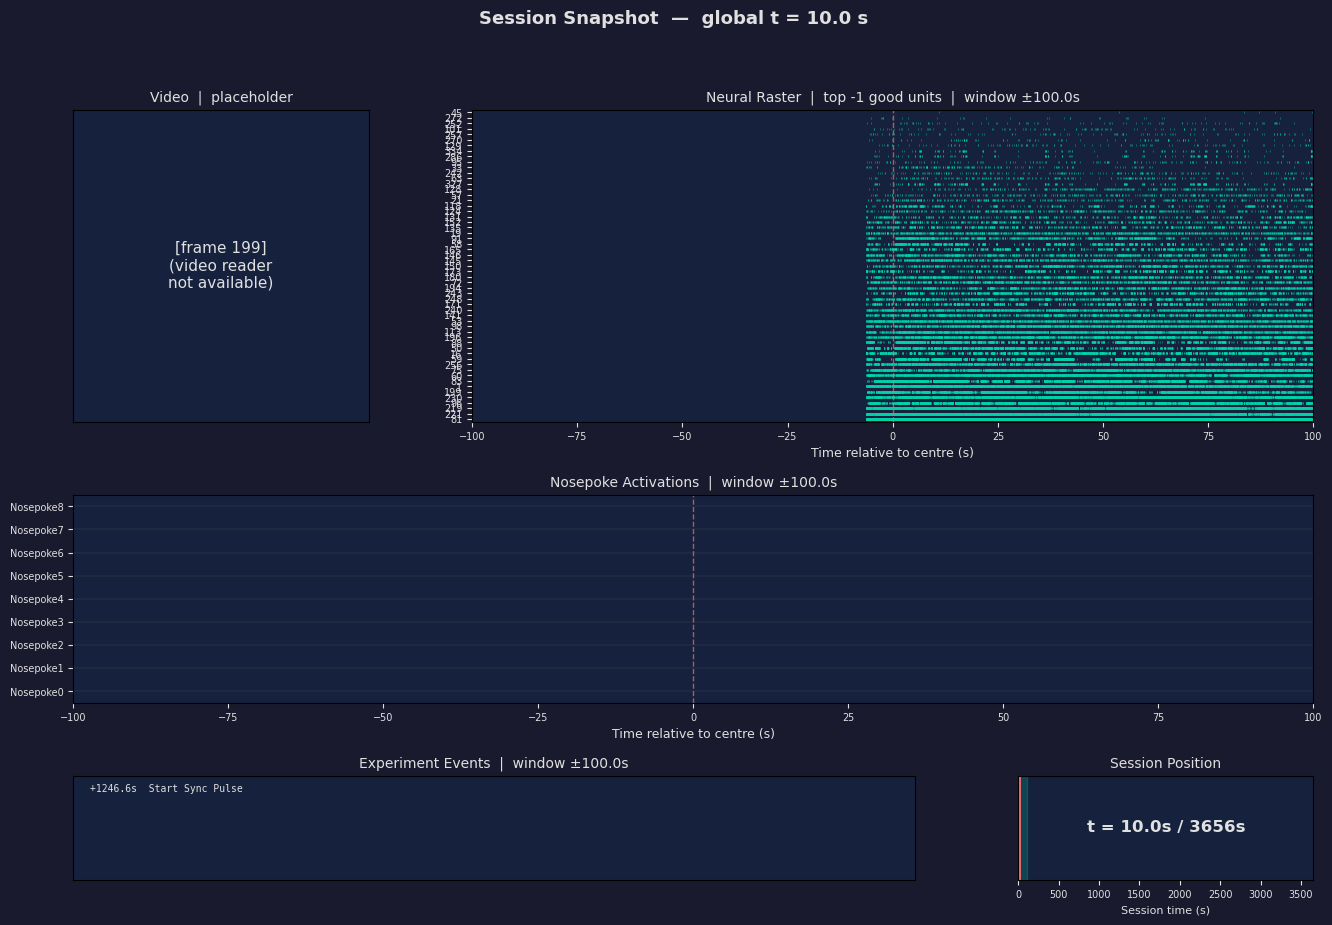

In [34]:
#======== 8.4 Render a snapshot at t=240s (≈4 min into session) =================
# Change t_center to explore different moments; window_sec controls context width

session_snapshot(t_center=10.0, window_sec=100.0, n_clusters_to_show=-1)

----
## 9. Useful information and links

- [Bonsai](https://bonsai-rx.org/) — Visual reactive programming for experimental control
- [HARP](https://harp-tech.org/) — Hardware timestamped acquisition protocol
- [harp-python](https://pypi.org/project/harp-python/) — Python API for HARP devices
- [NeuroBlueprint](https://neuroblueprint.neuroinformatics.dev/) — Standardised directory structure for neuroscience data
- [datashuttle](https://datashuttle.neuroinformatics.dev/) — Data management and transfer
- [movement](https://movement.neuroinformatics.dev/) — Pose tracking analysis
- [xarray](https://xarray.dev/) — N-dimensional labeled arrays and datasets